# Import Library

In [7]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import cv2
import requests
from io import BytesIO
import zipfile
import glob
import warnings

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model


warnings.filterwarnings('ignore')

In [6]:
! pip install seaborn
! pip install torch
! pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 14.5 MB/s eta 0:00:00


# Load CSV

In [8]:
import os
folder_path = '/Users/liuyueyang/Desktop/BMI/Data'
print(os.listdir(folder_path))  #  ['images', 'data.csv']

['.DS_Store', 'Images', 'Untitled.ipynb', 'data.csv', 'clean_bmi_data.csv', '.ipynb_checkpoints']


In [9]:
import pandas as pd

# Paths
csv_path = os.path.join(folder_path, 'clean_bmi_data.csv')
image_dir = os.path.join(folder_path, 'Images')

# Load CSV
df = pd.read_csv(csv_path)
df.head()

,bmi,gender,is_training,name
0,34.207396,Male,1,img_0.bmp
1,26.453720,Male,1,img_1.bmp
2,34.967561,Female,1,img_2.bmp
3,22.044766,Female,1,img_3.bmp
4,25.845588,Female,1,img_6.bmp


In [10]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Basic EDA

Total samples: 3962
Training samples: 3210
Test samples: 752


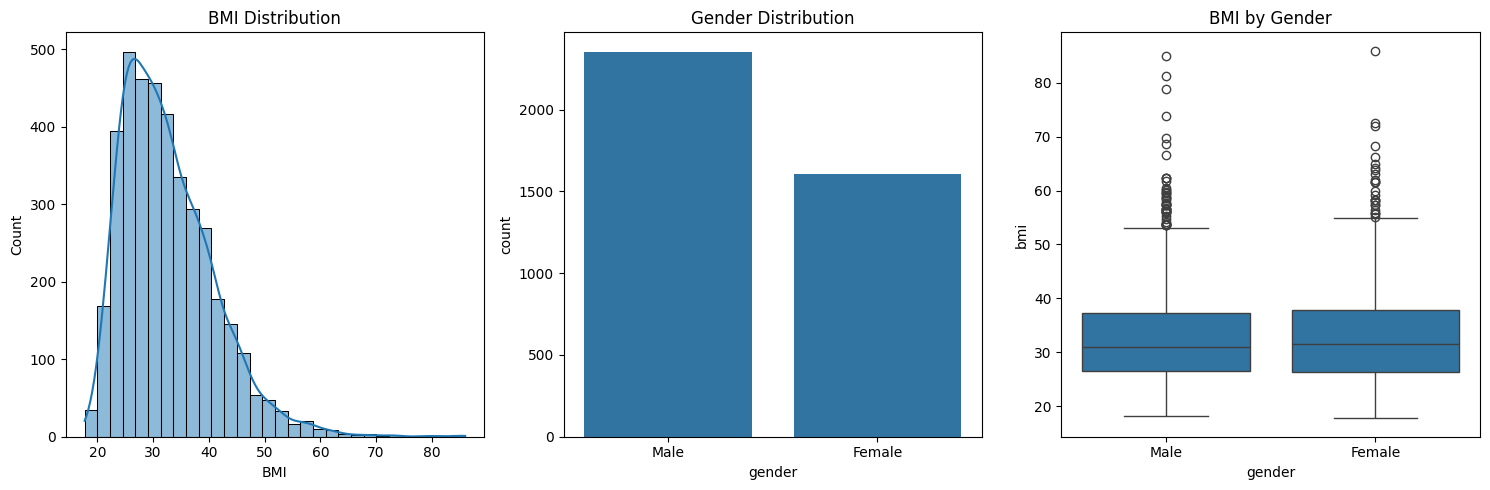

In [11]:
### Load Dataset
print(f"Total samples: {len(df)}")
print(f"Training samples: {sum(df['is_training'] == 1)}")
print(f"Test samples: {sum(df['is_training'] == 0)}")

# Display data distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['bmi'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')

plt.subplot(1, 3, 2)
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(x='gender', y='bmi', data=df)
plt.title('BMI by Gender')

plt.tight_layout()
plt.show()

In [12]:
# Split the data into training and testing
train_df = df[df['is_training'] == 1].reset_index(drop=True)
test_df = df[df['is_training'] == 0].reset_index(drop=True)

print(f"Training set: {len(train_df)} samples")
print(f"Testing set: {len(test_df)} samples")

Training set: 3210 samples
Testing set: 752 samples


In [13]:
image_dir

'/Users/liuyueyang/Desktop/BMI/Data/Images'

# Load Images

In [14]:
from PIL import Image
import numpy as np
from tensorflow.keras.applications.vgg16 import preprocess_input
from tqdm import tqdm
import os

IMG_SIZE = (224, 224)

def load_images_pil(df, image_dir):
    images = []
    bmis = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = os.path.join(image_dir, row['name'])
        try:
            img = Image.open(path).convert("RGB")  # ensure 3-channel RGB
            img = img.resize(IMG_SIZE)  # resize to 224x224
            img_array = np.array(img).astype(np.float32) # # VGG16 preprocessing, VGG16-specific normalization
            img_array = preprocess_input(img_array)
            images.append(img_array)
            bmis.append(row['bmi'])
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue
    return np.array(images), np.array(bmis)

In [15]:
# Split based on the 'is_training' column in CSV
train_df = df[df['is_training'] == 1].reset_index(drop=True)
valid_df = df[df['is_training'] == 0].reset_index(drop=True)

# # Load preprocessed image arrays and BMI values
X_train_img, y_train = load_images_pil(train_df,image_dir)
X_valid_img, y_valid = load_images_pil(valid_df,image_dir)

100%|██████████| 752/752 [00:02<00:00, 332.43it/s]


# 1. VGG16 Model -- extract features

In [16]:
# Extract Deep Features Using Pretrained VGG16
# Load the full VGG16 model pretrained on ImageNet
base_model = VGG16(weights='imagenet', include_top=True, input_shape=(224, 224, 3))# include_top=True means we keep the fully connected layers

# We only want the output from the 'fc1' layer (first fully connected layer)
# Why fc1 is used in this case: It contains general semantic features, not yet specific to ImageNet categories.
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc1').output)

# Extract features
X_train_feat = model.predict(X_train_img, batch_size=32, verbose=1)
X_valid_feat = model.predict(X_valid_img, batch_size=32, verbose=1)
#  The results here are 4096-dimensional feature vector per image (from VGG16’s fc1 layer)
#  batch_size=32: Instead of processing all images at once, the model processes them in small groups of 32 images at a time.
#  verbose=1: Shows progress bar during prediction

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 134s 0us/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step


In [17]:
# List all layers in VGG16 (with their names and output shapes, if available)
for i, layer in enumerate(base_model.layers):
        print(f"{i:2d}: {layer.name:20s} ")

 0: input_layer          
 1: block1_conv1         
 2: block1_conv2         
 3: block1_pool          
 4: block2_conv1         
 5: block2_conv2         
 6: block2_pool          
 7: block3_conv1         
 8: block3_conv2         
 9: block3_conv3         
10: block3_pool          
11: block4_conv1         
12: block4_conv2         
13: block4_conv3         
14: block4_pool          
15: block5_conv1         
16: block5_conv2         
17: block5_conv3         
18: block5_pool          
19: flatten              
20: fc1                  
21: fc2                  
22: predictions          


##### VGG16 Layer Types and Their Roles
1. InputLayer
Shape: (224, 224, 3)
Purpose: Acts as a placeholder for input images (RGB, 224x224).
Note: Doesn’t perform computation; it defines the expected shape for downstream layers.
2. Conv2D (e.g., block1_conv1, block1_conv2, …)
Operation: Applies multiple learnable filters (3x3 in VGG16) across the image.
* Purpose:
-  Detects patterns such as edges, corners, and textures.
-  Deeper conv layers detect shapes, parts, and objects.
* Activation: ReLU (introduces non-linearity)
* Why it matters: These layers extract hierarchical features from the image.
3. MaxPooling2D (e.g., block1_pool)
Operation: Reduces spatial size (height/width) by taking the maximum value in a region (typically 2x2).
Purpose:
* Downsamples feature maps to reduce computation
* Makes the model more robust to small translations in the image
Why it matters: Helps the model generalize better and reduces parameters.
4. Flatten
* Operation: Converts the 3D output from the last convolutional block into a 1D vector.
* Purpose: Prepares the data for the fully connected (dense) layers.
* Why it matters: Transition point from spatial processing (conv layers) to abstract classification/regression (dense layers).

5. Dense / Fully Connected Layers
* a. fc1 (Dense 4096)
Learns high-level, abstract patterns (e.g., overall face structure, shape)

Used as a feature extractor in transfer learning (like for BMI prediction)

* b. fc2 (Dense 4096)
Further refines features toward ImageNet classification (task-specific)

* c. predictions (Dense 1000, Softmax)
Final classifier layer for ImageNet with 1000 categories
Outputs probabilities across all 1000 classes


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_valid_scaled = scaler.transform(X_valid_feat) # use the same scaling rule learned from the training data

##  1.1 SVR (Support Vector Regression (SVR))

In [19]:
# Train SVR (Support Vector Regression (SVR))
# SVR is a good choice becasue of its robust generalization behavior.
svr = SVR(kernel='linear')
svr.fit(X_train_scaled, y_train)

# Predict
y_pred = svr.predict(X_valid_scaled)

In [20]:
# RMSE: Penalizes large errors (squared error)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Validation RMSE: {rmse:.2f}')

Validation RMSE: 81.13


In [21]:
# Pearson Correlation Coefficient (r): Measures linear association between actual and predicted BMI
from scipy.stats import pearsonr
r, _ = pearsonr(y_valid, y_pred)
print(f'Pearson correlation: r = {r:.3f}')

Pearson correlation: r = 0.106


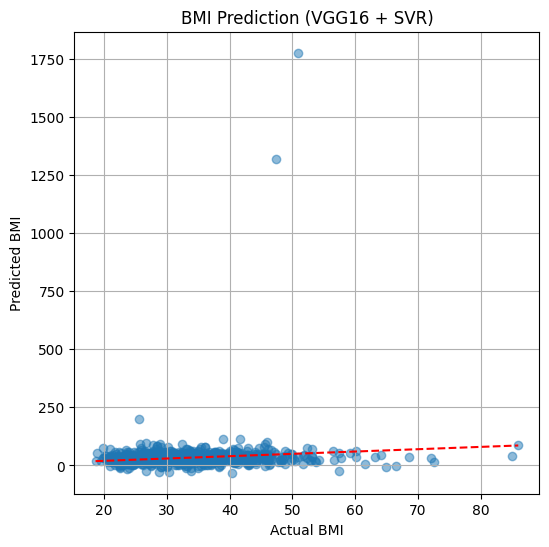

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, y_pred, alpha=0.5)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], 'r--')
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("BMI Prediction (VGG16 + SVR)")
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
print(f"RMSE: {np.sqrt(mean_squared_error(y_valid, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_valid, y_pred):.2f}")
print(f"R²: {r2_score(y_valid, y_pred):.3f}")
print(f"Pearson r: {pearsonr(y_valid, y_pred)[0]:.3f}")

RMSE: 81.13
MAE: 19.78
R²: -76.526
Pearson r: 0.106


##  1.2 Simple Multi-Layer Perceptron (MLP)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [26]:
def create_mlp_model(input_dim=4096):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='linear'))  # Output layer for BMI (regression)
    
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['mae'])
    return model

In [27]:
mlp_model = create_mlp_model(input_dim=X_train_scaled.shape[1])

history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=50,
    batch_size=32,
    verbose=1)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 717.5638 - mae: 24.6393 - val_loss: 4113.1836 - val_mae: 11.0101
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 72.6836 - mae: 6.6462 - val_loss: 4137.7446 - val_mae: 10.1342
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 51.1105 - mae: 5.5141 - val_loss: 4264.7681 - val_mae: 10.1465
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 42.6113 - mae: 5.0561 - val_loss: 4385.2090 - val_mae: 10.2269
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 37.2301 - mae: 4.7097 - val_loss: 4690.8350 - val_mae: 10.2748
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 33.7412 - mae: 4.4587 - val_loss: 4770.3945 - val_mae: 10.1833
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 26.5919 - mae: 3.9476 - val_loss: 4709.2993 - val_mae: 10.1824
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 26.4504 - mae: 3.9292 - val_loss: 4903.4849 - val_mae: 10.2781
Epoch 9/50


In [28]:
# Predict
y_pred_mlp = mlp_model.predict(X_valid_scaled).flatten()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [29]:
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
print(f"RMSE: {np.sqrt(mean_squared_error(y_valid, y_pred_mlp)):.2f}")
print(f"MAE: {mean_absolute_error(y_valid, y_pred_mlp):.2f}")
print(f"R²: {r2_score(y_valid, y_pred_mlp):.3f}")
print(f"Pearson r: {pearsonr(y_valid, y_pred_mlp)[0]:.3f}")

RMSE: 79.27
MAE: 11.17
R²: -73.011
Pearson r: 0.106


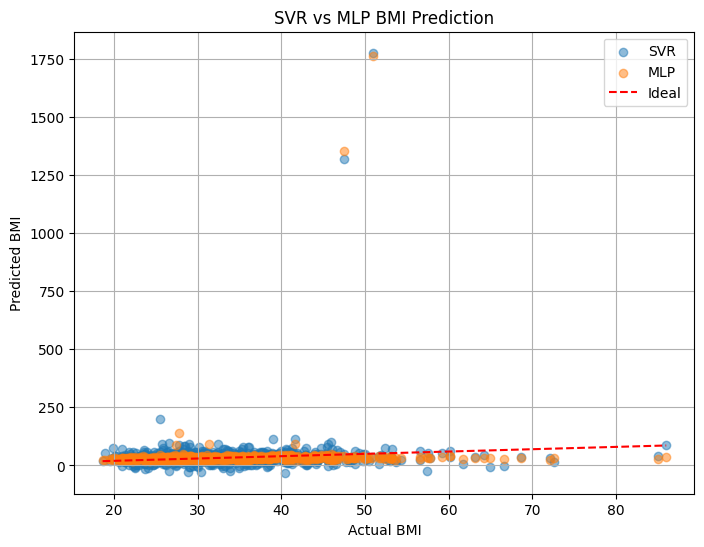

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_valid, y_pred, label='SVR', alpha=0.5)
plt.scatter(y_valid, y_pred_mlp, label='MLP', alpha=0.5)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], 'r--', label='Ideal')
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("SVR vs MLP BMI Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
! pip install tensorflow keras keras-vggface

# 2. VGG Face

In [50]:
from tensorflow.keras.applications.vgg16 import VGG16

# VGG
model = VGG16(include_top=False, pooling='avg', input_shape=(224,224,3))
model.load_weights('/Users/liuyueyang/Desktop/Final_Project/rcmalli_vggface_tf_vgg16.h5',by_name=True,
    skip_mismatch=True
)


In [51]:
# Extract features
X_train_feat = model.predict(X_train_img, batch_size=32, verbose=1)
X_valid_feat = model.predict(X_valid_img, batch_size=32, verbose=1)

101/101 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step


In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_valid_scaled = scaler.transform(X_valid_feat)

svr = SVR(kernel='linear')
svr.fit(X_train_scaled, y_train)

SVR(kernel='linear')

In [53]:
y_pred = svr.predict(X_valid_scaled)
print(f"RMSE: {np.sqrt(mean_squared_error(y_valid, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_valid, y_pred):.2f}")
print(f"R²: {r2_score(y_valid, y_pred):.3f}")
print(f"Pearson r: {pearsonr(y_valid, y_pred)[0]:.3f}")

RMSE: 9.16
MAE: 6.63
R²: 0.011
Pearson r: 0.347


In [54]:
def create_mlp_model(input_dim=4096):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='linear'))  # Output layer for BMI (regression)
    
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['mae'])
    return model

In [55]:
mlp_model = create_mlp_model(input_dim=X_train_scaled.shape[1])

history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=50,
    batch_size=32,
    verbose=1)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 799.5809 - mae: 26.5887 - val_loss: 225.2214 - val_mae: 11.7652
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 132.3548 - mae: 8.8301 - val_loss: 119.1243 - val_mae: 8.1352
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 84.0707 - mae: 7.1440 - val_loss: 104.6050 - val_mae: 7.5401
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 76.6013 - mae: 6.7865 - val_loss: 95.8616 - val_mae: 7.2245
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 68.5217 - mae: 6.4012 - val_loss: 93.3759 - val_mae: 7.0806
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63.5991 - mae: 6.1384 - val_loss: 92.2654 - val_mae: 7.0377
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 59.8653 - mae: 5.9988 - val_loss: 89.8125 - val_mae: 7.0119
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56.6723 - mae: 5.8414 - val_loss: 90.8087 - val_mae: 6.9692
Epoch 9/50
101/101 ━━━━━━━━━━━━━━

In [56]:
# Predict
y_pred_mlp = mlp_model.predict(X_valid_scaled).flatten()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [57]:
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
print(f"RMSE: {np.sqrt(mean_squared_error(y_valid, y_pred_mlp)):.2f}")
print(f"MAE: {mean_absolute_error(y_valid, y_pred_mlp):.2f}")
print(f"R²: {r2_score(y_valid, y_pred_mlp):.3f}")
print(f"Pearson r: {pearsonr(y_valid, y_pred_mlp)[0]:.3f}")

RMSE: 9.60
MAE: 7.06
R²: -0.085
Pearson r: 0.280


# 3. Facenet Model

## 3.1 Load images by using facenet

In [59]:
! pip install facenet_pytorch 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 24.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 MB 23.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.2.1
    Uninstalling pillow-11.2.1:
      Successfully uninstalled pillow-11.2.1
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━ 0/5 [Pillow]
    Found existing installation: numpy 2.1.3 0/5 [Pillow]
    Uninstalling numpy-2.1.3:━━━━━━━━━━━━━━━ 0/5 [Pillow]
      Successfully uninstalled numpy-2.1.3━━ 0/5 [Pillow]
  Attempting uninstall: torchm━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Found existing installation: torch 2.7.0━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Uninstalling torch-2.7.0:╺━━━━━━━━━━━━━━━━━━━━━━━

In [65]:
! pip install tensorflow mtcnn pillow


In [67]:
from mtcnn import MTCNN
import tensorflow as tf

In [72]:
! pip install keras-facenet


  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'keras-facenet' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'keras-facenet'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10369 sha256=ef1c85d378ae33bb2778706e1b99e91b00fc133ef55e1e45306a6693036fab2e
  Stored in directory: /Users/liuyueyang/Library/Caches/pip/wheels/1d/d8/a9/85cf04ea29321d2afcb82c0caaafdca9195385f9d68cbc7185
Successfully built keras-facenet


In [74]:
from keras_facenet import FaceNet

embedder = FaceNet()

def load_embeddings_facenet(df: pd.DataFrame, image_dir: str):
    """
Input:
-df: A DataFrame containing the columns 'name' (file name) and 'bmi'
-image_dir: The directory for storing pictures
Output:
-X: An embedded array of (N,128)
-y: The BMI array of (N,)

    """
    embeddings, bmis = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = os.path.join(image_dir, row['name'])
        try:
            # read image
            img = Image.open(path).convert('RGB')
            arr = np.asarray(img)

            # FaceNet embedding
            res = embedder.extract(arr, threshold=0.90)
            if not res:
                print(f"No face detected: {path}")
                continue

            emb = res[0]['embedding']  # 128-d 
            embeddings.append(emb)
            bmis.append(row['bmi'])
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue

    return np.vstack(embeddings), np.array(bmis)

In [75]:
# —— 3. 加载 train/valid 嵌入 —— 
image_dir = '/Users/liuyueyang/Desktop/BMI/Data/Images'  # 替换成你的图片文件夹
X_train, y_train = load_embeddings_facenet(train_df, image_dir)
X_valid, y_valid = load_embeddings_facenet(valid_df, image_dir)

  0%|          | 0/3210 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step


  0%|          | 1/3210 [00:01<57:45,  1.08s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  0%|          | 3/3210 [00:01<18:05,  2.95it/s]

...

100%|█████████▉| 749/752 [01:16<00:00, 10.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


100%|█████████▉| 751/752 [01:16<00:00, 10.34it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


100%|██████████| 752/752 [01:16<00:00,  9.83it/s]


## 3.2 Model

In [76]:
def build_regressor(input_dim=128):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_regressor(input_dim=X_train.shape[1])

# —— 5. 训练 —— 
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=32
)

# —— 6. 在验证集上预测 —— 
y_pred = model.predict(X_valid).ravel()

# —— 7. 计算并展示各项指标 —— 
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae  = mean_absolute_error(y_valid, y_pred)
r2   = r2_score(y_valid, y_pred)
pearson_r, _ = pearsonr(y_valid, y_pred)

metrics_df = pd.DataFrame({
    'Metric':    ['RMSE', 'MAE', 'R²', 'Pearson r'],
    'Value':     [rmse, mae, r2, pearson_r]
})
# 格式化数值到三位小数
metrics_df['Value'] = metrics_df['Value'].map(lambda x: f"{x:.3f}")

print(metrics_df.to_string(index=False))

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1113.5872 - mae: 32.3985 - val_loss: 1173.6595 - val_mae: 33.0212
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1051.9470 - mae: 31.5133 - val_loss: 1097.9636 - val_mae: 31.9126
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 974.7822 - mae: 30.2928 - val_loss: 1002.5237 - val_mae: 30.4498
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 893.3777 - mae: 28.9902 - val_loss: 890.8206 - val_mae: 28.6331
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 768.7101 - mae: 26.8757 - val_loss: 770.8077 - val_mae: 26.5269
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - loss: 693.0967 - mae: 25.3643 - val_loss: 649.9451 - val_mae: 24.1984
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 574.4280 - mae: 22.9225 - val_loss: 535.3198 - val_mae: 21.7271
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 464.6798 - mae: 20.4478 - val_loss: 432.4803 - val_mae: 19.2012

In [1]:
from keras_facenet import FaceNet
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

"""
# ——— 1.  FaceNet Model ———
embedder = FaceNet()            
base_model = embedder.model   # 这是一个 tf.keras.Model input (160,160,3) output 128-d

# ——— 2. Freeze most layers, leaving only the last few layers available for training ———
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# ——— 3. Take a stronger return head
x = base_model.output
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
pred = Dense(1, activation='linear', name='bmi')(x)

model = Model(inputs=base_model.input, outputs=pred)

# ——— 4. Compilation: A smaller learning rate, using Adam + learning rate decay ———
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='mse',
    metrics=['mae']
)
#model.summary()

"""


In [90]:
import tensorflow as tf

def preprocess(path, label):
    # Read binary
    img_bytes = tf.io.read_file(path)
    # Automatically recognize formats such as JPEG/PNG/BMP, and return a uint8 Tensor. Static images do not contain the frame dimension
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    # If the shape after decode_image is [None, None, 3], it can be explicitly declared for subsequent resize
    img.set_shape([None, None, 3])
    # Adjust to a fixed size and normalize to [-1,1]
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 127.5 - 1.0

    # Data Augmentation (Automatically applied only during training)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.2)
    return img, label

train_paths = [os.path.join(image_dir, fn) for fn in train_df['name']]
train_labels = train_df['bmi'].values

valid_paths = [os.path.join(image_dir, fn) for fn in valid_df['name']]
valid_labels = valid_df['bmi'].values

IMG_SIZE = (160,160)



In [97]:


train_ds = (
    tf.data.Dataset
      .from_tensor_slices((train_paths, train_labels))
      .shuffle(len(train_paths))
      .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(32)
      .prefetch(tf.data.AUTOTUNE)
)

valid_ds = (
    tf.data.Dataset
      .from_tensor_slices((valid_paths, valid_labels))
      .map(lambda p, l: preprocess(p, l)[0:2], num_parallel_calls=tf.data.AUTOTUNE)
      .batch(32)
      .prefetch(tf.data.AUTOTUNE)
)

In [98]:
embedder = FaceNet()
backbone = embedder.model  

#  Freeze most layers, leaving only the last few layers available for training 
for layer in backbone.layers[:-20]:
    layer.trainable = False
for layer in backbone.layers[-20:]:
    layer.trainable = True


In [99]:
# Take a stronger return head
x = backbone.output
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
pred = Dense(1, activation='linear', name='bmi')(x)

model = Model(inputs=backbone.input, outputs=pred)


In [100]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

In [101]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 336ms/step - loss: 1160.5916 - mae: 33.1255 - val_loss: 1194.5544 - val_mae: 33.3318 - learning_rate: 5.0000e-05
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 335ms/step - loss: 977.4948 - mae: 30.4422 - val_loss: 1121.5897 - val_mae: 32.3314 - learning_rate: 5.0000e-05
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 319ms/step - loss: 698.2104 - mae: 25.5735 - val_loss: 915.0240 - val_mae: 29.1812 - learning_rate: 5.0000e-05
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 329ms/step - loss: 329.8141 - mae: 16.6318 - val_loss: 583.8733 - val_mae: 22.9569 - learning_rate: 5.0000e-05
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 339ms/step - loss: 129.9040 - mae: 9.4692 - val_loss: 284.2916 - val_mae: 15.1693 - learning_rate: 5.0000e-05
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 327ms/step - loss: 73.6181 - mae: 6.6770 - val_loss: 117.6745 - val_mae: 8.3999 - learning_rate: 5.0000e-05
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - loss: 57.7835 

In [ ]:
# —— 8. Evaluation metrix —— 
y_pred = model.predict(valid_ds).ravel()
rmse      = np.sqrt(mean_squared_error(valid_labels, y_pred))
mae       = mean_absolute_error(valid_labels, y_pred)
r2        = r2_score(valid_labels, y_pred)
pearson_r = pearsonr(valid_labels, y_pred)[0]

print(f"RMSE:       {rmse:.2f}")
print(f"MAE:        {mae:.2f}")
print(f"R²:         {r2:.3f}")
print(f"Pearson r:  {pearson_r:.3f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step
RMSE:       6.86
MAE:        5.07
R²:         0.446
Pearson r:  0.674
